# Phase 2 — Notebook 1: SVM Implementation, Tuning, and Evaluation

**Dataset:** Healthcare Stroke Prediction  
**Authors:** Bora   
**Course:** Machine Learning — UNYT, 2026

This notebook focuses only on the **Support Vector Machine (SVM)** model for the stroke prediction dataset.
It is based on the Phase 2 structure you already used, but split into a cleaner standalone notebook.

## Goals
- Load the preprocessed Phase 1 outputs when available
- Train an SVM classifier
- Tune hyperparameters with `GridSearchCV`
- Evaluate with cross-validation and test-set metrics
- Visualize confusion matrix and ROC curve

In [1]:
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, classification_report, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder, StandardScaler

try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Data

We first try to load the **processed outputs from Phase 1**:
- `X_train.csv`
- `X_test.csv`
- `y_train.csv`
- `y_test.csv`
- optionally `X_train_smote.csv` and `y_train_smote.csv`

If these files are not found, the notebook falls back to rebuilding the preprocessing directly from the raw dataset.

In [2]:
base_candidates = [
    Path("../outputs"),
    Path("outputs"),
    Path("../data"),
    Path("data"),
]

output_dir = None
for candidate in [Path("../outputs"), Path("outputs")]:
    if (candidate / "X_train.csv").exists():
        output_dir = candidate
        break

def load_phase1_outputs():
    X_train = pd.read_csv(output_dir / "X_train.csv")
    X_test = pd.read_csv(output_dir / "X_test.csv")
    y_train = pd.read_csv(output_dir / "y_train.csv").squeeze("columns")
    y_test = pd.read_csv(output_dir / "y_test.csv").squeeze("columns")

    X_train_smote_path = output_dir / "X_train_smote.csv"
    y_train_smote_path = output_dir / "y_train_smote.csv"

    if X_train_smote_path.exists() and y_train_smote_path.exists():
        X_train_smote = pd.read_csv(X_train_smote_path)
        y_train_smote = pd.read_csv(y_train_smote_path).squeeze("columns")
    else:
        X_train_smote, y_train_smote = None, None

    return X_train, X_test, y_train, y_test, X_train_smote, y_train_smote

def rebuild_from_raw():
    raw_candidates = [
        Path("../data/healthcare-dataset-stroke-data.csv"),
        Path("data/healthcare-dataset-stroke-data.csv"),
        Path("healthcare-dataset-stroke-data.csv"),
    ]

    raw_path = None
    for candidate in raw_candidates:
        if candidate.exists():
            raw_path = candidate
            break

    if raw_path is None:
        raise FileNotFoundError(
            "Could not find Phase 1 outputs or the raw dataset. "
            "Please place the dataset in a data folder or run preprocessing first."
        )

    df = pd.read_csv(raw_path)
    df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")
    if "id" in df.columns:
        df = df.drop(columns=["id"])
    df = df[df["gender"] != "Other"].copy()

    le = LabelEncoder()
    for col in ["gender", "ever_married", "Residence_type"]:
        df[col] = le.fit_transform(df[col])

    df = pd.get_dummies(df, columns=["work_type", "smoking_status"], drop_first=False)

    target = "stroke"
    numerical_features = ["age", "avg_glucose_level", "bmi"]

    X = df.drop(columns=[target])
    y = df[target]

    X["bmi"] = X["bmi"].fillna(X["bmi"].median())

    scaler = StandardScaler()
    X_scaled = X.copy()
    X_scaled[numerical_features] = scaler.fit_transform(X[numerical_features])

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )

    if IMBLEARN_AVAILABLE:
        smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
        X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
        X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)
        y_train_smote = pd.Series(y_train_smote, name="stroke")
    else:
        X_train_smote, y_train_smote = None, None

    return X_train, X_test, y_train, y_test, X_train_smote, y_train_smote

if output_dir is not None:
    X_train, X_test, y_train, y_test, X_train_smote, y_train_smote = load_phase1_outputs()
    print(f"Loaded Phase 1 outputs from: {output_dir.resolve()}")
else:
    X_train, X_test, y_train, y_test, X_train_smote, y_train_smote = rebuild_from_raw()
    print("Phase 1 outputs not found, so preprocessing was rebuilt from raw data.")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts())

Loaded Phase 1 outputs from: C:\Users\PC\Documents\Machine Learning\ML project\Stroke_Prediction\outputs
X_train: (4087, 17)
X_test : (1022, 17)
y_train distribution:
stroke
0    3888
1     199
Name: count, dtype: int64


## 2. Choose Training Data

Because stroke prediction is an imbalanced classification problem, we use **SMOTE-balanced training data** when available.
The test set always remains untouched and keeps the original distribution.

In [3]:
if X_train_smote is not None and y_train_smote is not None:
    X_fit = X_train_smote.copy()
    y_fit = y_train_smote.copy()
    print("Using SMOTE-balanced training data.")
    print("Balanced class counts:")
    print(y_fit.value_counts())
else:
    X_fit = X_train.copy()
    y_fit = y_train.copy()
    print("SMOTE data not found. Using original training data.")

Using SMOTE-balanced training data.
Balanced class counts:
stroke
0    3888
1    3888
Name: count, dtype: int64


## 3. Hyperparameter Tuning for SVM

We tune:
- `C`
- `kernel`
- `gamma`

`GridSearchCV` uses **5-fold stratified cross-validation** and optimizes **ROC-AUC**, which is more informative than accuracy for imbalanced data.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

svm_param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale", "auto"]
}

svm_base = SVC(probability=True, random_state=RANDOM_STATE)

svm_grid = GridSearchCV(
    estimator=svm_base,
    param_grid=svm_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0
)

start = time.time()
svm_grid.fit(X_fit, y_fit)
svm_train_time = time.time() - start

best_svm = svm_grid.best_estimator_

print("Best parameters:", svm_grid.best_params_)
print(f"Best CV ROC-AUC: {svm_grid.best_score_:.4f}")
print(f"Training time: {svm_train_time:.2f} seconds")

Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV ROC-AUC: 0.9782
Training time: 222.83 seconds


## 4. Cross-Validation Performance

In [5]:
svm_cv_acc = cross_val_score(best_svm, X_fit, y_fit, cv=cv, scoring="accuracy")
svm_cv_f1 = cross_val_score(best_svm, X_fit, y_fit, cv=cv, scoring="f1")
svm_cv_auc = cross_val_score(best_svm, X_fit, y_fit, cv=cv, scoring="roc_auc")

print("5-Fold Cross-Validation Results")
print(f"Accuracy: {svm_cv_acc.mean():.4f} ± {svm_cv_acc.std():.4f}")
print(f"F1-Score: {svm_cv_f1.mean():.4f} ± {svm_cv_f1.std():.4f}")
print(f"ROC-AUC : {svm_cv_auc.mean():.4f} ± {svm_cv_auc.std():.4f}")

5-Fold Cross-Validation Results
Accuracy: 0.9302 ± 0.0072
F1-Score: 0.9334 ± 0.0067
ROC-AUC : 0.9782 ± 0.0023


## 5. Test Set Evaluation

In [6]:
y_pred_svm = best_svm.predict(X_test)
y_proba_svm = best_svm.predict_proba(X_test)[:, 1]

svm_results = {
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm, zero_division=0),
    "Recall": recall_score(y_test, y_pred_svm, zero_division=0),
    "F1-Score": f1_score(y_test, y_pred_svm, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_svm),
    "Train Time (s)": svm_train_time
}

results_df = pd.DataFrame([svm_results]).round(4)
results_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s)
0,0.863,0.1121,0.26,0.1566,0.745,222.8321


In [7]:
print("Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=["No Stroke", "Stroke"], zero_division=0))

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.96      0.89      0.93       972
      Stroke       0.11      0.26      0.16        50

    accuracy                           0.86      1022
   macro avg       0.54      0.58      0.54      1022
weighted avg       0.92      0.86      0.89      1022



## 6. Confusion Matrix

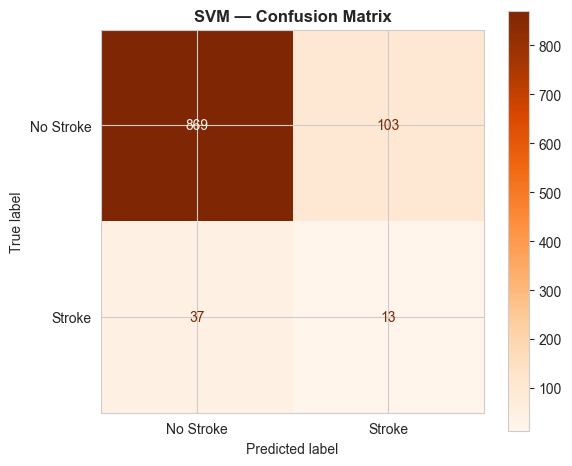

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=["No Stroke", "Stroke"],
    cmap="Oranges",
    ax=ax
)
ax.set_title("SVM — Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. ROC Curve

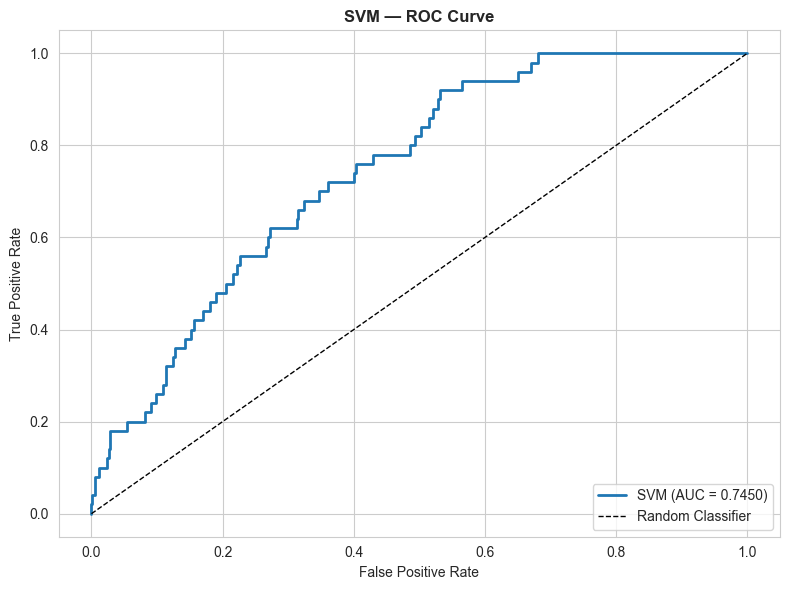

In [9]:
fpr, tpr, _ = roc_curve(y_test, y_proba_svm)
auc_value = roc_auc_score(y_test, y_proba_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"SVM (AUC = {auc_value:.4f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM — ROC Curve", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Final SVM Summary

In [10]:
print("=" * 60)
print("SVM FINAL SUMMARY")
print("=" * 60)
for metric, value in svm_results.items():
    if metric == "Train Time (s)":
        print(f"{metric}: {value:.2f}")
    else:
        print(f"{metric}: {value:.4f}")
print("=" * 60)

SVM FINAL SUMMARY
Accuracy: 0.8630
Precision: 0.1121
Recall: 0.2600
F1-Score: 0.1566
ROC-AUC: 0.7450
Train Time (s): 222.83
